**Table of contents**<a id='toc0_'></a>    
- [Fluopy trials notebook](#toc1_)    
  - [Importing all modules](#toc1_1_)    
  - [Routine template](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Fluopy trials notebook](#toc0_)
This notebook is dedicated to test functionality of fluopy

## <a id='toc1_1_'></a>[Importing all modules](#toc0_)

In [20]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", count=2, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    dstorm=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

In [67]:
fluorophore1 = fl.Fluorophore(name="cy5_dna", position=[0, 0, 0])
fluorophore2 = fl.Fluorophore(name="cy5_dna", position=[3, 0, 0])
fluorophore3 = fl.Fluorophore(name="cy5_dna", position=[0, 3, 0])
fluorophore4 = fl.Fluorophore(name="cy5_dna", position=[3, 3, 0])
fluorophore_system = fl.FluorophoreSystem(
    fluorophores=[fluorophore1, fluorophore2, fluorophore3]
)  # , fluorophore4])

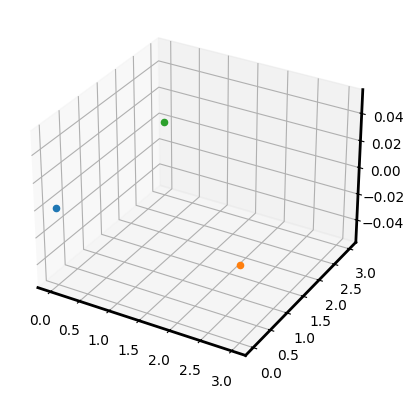

In [68]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
for fluorophore in fluorophore_system.fluorophores:
    ax.scatter(
        fluorophore.position[0],
        fluorophore.position[1],
        fluorophore.position[2],
        label=fluorophore.name,
    )

In [77]:
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    dstorm=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

In [ ]:
emis = em.Emissions()
emis.tcspc(
    details=True,
    transition_set=transition_set,
    number_pulses=4e7,
    store_time_points=True,
    time_between_pulses=1e-6,
)

The irradiance used initially for excitation rates in
 transition_set is now assumed to be the mean irradiance of
 pulse and no pulse duration.
Floating point precision error warning:
 The smallest safe increment is 7.11e-15.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1, 1, 1]
 gives a probability of 1.67e-05 for a smaller increment to be drawn.
the last frame (of index 40.0) has 0.00e+00 times the pulses of other frames.
Multiple excitations at the same time point are spaced by a minimal amount. This also spaces other transitions whose time was too small to be differentiated given the floating point precision. Hence, transitions with mean time lower than expected will now have mean time higher than expected.


MemoryError: 

: 

In [33]:
_, _, _, simulation = Out[26]

In [35]:
hist, bins = fcs_p.coincidence(emis.event_time_points, 1e-6, 2e-10, 1)

In [36]:
emis2 = em.Emissions()
emis2.extract(simulation)

In [37]:
hist2, bins2 = fcs_p.coincidence(emis2.event_time_points, 1e-6, 2e-10, 1)

array([0.50746865, 0.55349206, 0.62482834, 0.71178836, 0.80262404,
       0.78142905, 0.70452151, 0.62228494, 0.55676214, 0.49232937])

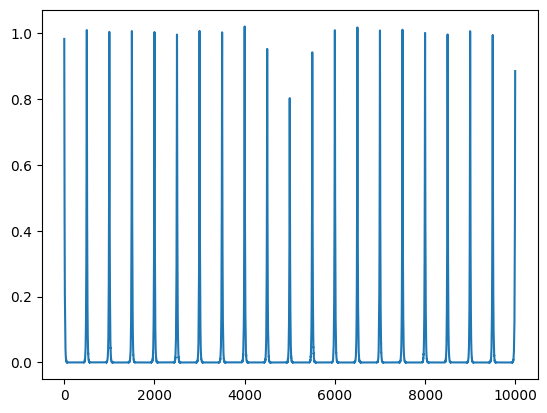

In [47]:
peaks, _ = find_peaks(hist, height=25)
normalize_to = hist[peaks[np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])]].mean()
normalized = hist / normalize_to
plt.plot(normalized)
normalized[4995:5005]

array([0.50746865, 0.55349206, 0.62482834, 0.71178836, 0.80262404,
       0.78142905, 0.70452151, 0.62228494, 0.55676214, 0.49232937])

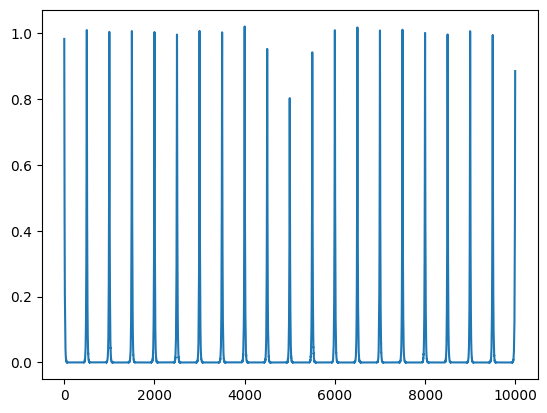

In [46]:
peaks, _ = find_peaks(hist2, height=25)
normalize_to = hist2[peaks[np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])]].mean()
normalized = hist2 / normalize_to
plt.plot(normalized)
normalized[4995:5005]